# Zig Zag Phenomenon
## Visualizing the Zig-Zag Phenomenon with Gradient Descent Momentum

## Problem Setup

We will visualize the "Zig-Zag" phenomenon using an ill-conditioned 2D quadratic loss:

$$f(x, y) = 0.1x^2 + 2y^2$$

## Tasks

### 1. Implement Gradient Descent with Momentum in Python

### 2. Run the Optimization

Run for **50 steps** starting from $x_0 = [10, 1]$ with fixed learning rate $\alpha = 0.1$.

Run three separate experiments:

- $\beta = 0$ — Standard Gradient Descent
- $\beta = 0.6$ — Moderate Momentum
- $\beta = 0.9$ — High Momentum

### 3. Trajectory Plot

Generate a single **2D contour plot** showing the trajectory (path) of $(x, y)$ for all three cases overlaid.

### 4. Loss vs. Iteration Plot

Generate a plot of $f(x_k, y_k)$ vs. Iteration Number using a **log-scale on the y-axis**.

**Question:** Which $\beta$ leads to the fastest convergence?

## Gradient Descent

In [10]:
import numpy as np 
import matplotlib.pyplot as plt

In [8]:
def objective(z):
    x, y = z[0], z[1]
    return 0.1 * x**2 + 2 * y**2

def compute_gradient(z):
    x, y = z[0], z[1]
    return np.array([0.2 * x, 4 * y])

def momentum_gd(z0, learning_rate=0.1, beta=0.9, epochs=50):
    z = np.array(z0, dtype=float)
    v = np.zeros(2)  # Velocity vector initialized to 0
    loss_history = []
    trajectory = [z.copy()]

    for i in range(epochs):
        grad = compute_gradient(z)

        # Momentum Update Rule
        # v_{k+1} = beta * v_k + alpha * grad
        v = beta * v + learning_rate * grad
        z -= v

        loss_history.append(objective(z))
        trajectory.append(z.copy())

    return z, loss_history, trajectory



## Visualizing 

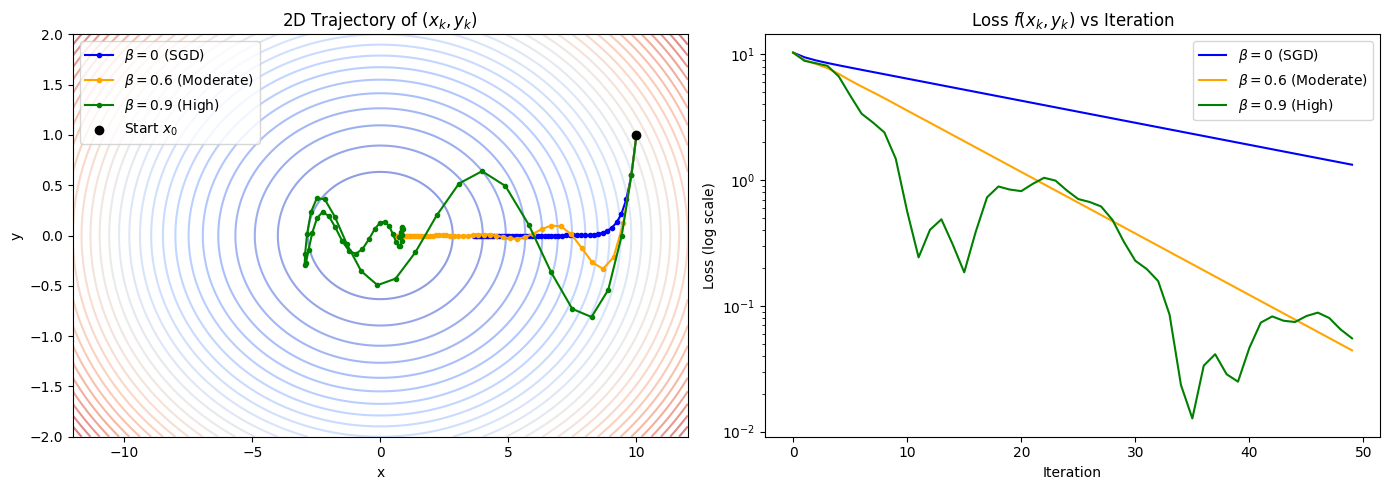

In [11]:

z0 = [10, 1]
alpha = 0.1
betas = [0, 0.6, 0.9]
labels = [r'$\beta = 0$ (SGD)', r'$\beta = 0.6$ (Moderate)', r'$\beta = 0.9$ (High)']
colors = ['blue', 'orange', 'green']

results = {}
for beta in betas:
    z_final, loss_hist, traj = momentum_gd(z0, learning_rate=alpha, beta=beta, epochs=50)
    results[beta] = {'loss': loss_hist, 'traj': np.array(traj)}

# --- Plot 1: 2D Trajectory ---
x_grid = np.linspace(-12, 12, 400)
y_grid = np.linspace(-2, 2, 400)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid = 0.1 * X_grid**2 + 2 * Y_grid**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.contour(X_grid, Y_grid, Z_grid, levels=30, cmap='coolwarm', alpha=0.6)
for beta, label, color in zip(betas, labels, colors):
    traj = results[beta]['traj']
    ax1.plot(traj[:, 0], traj[:, 1], 'o-', label=label, color=color, markersize=3)
ax1.scatter(*z0, color='black', zorder=5, label='Start $x_0$')
ax1.set_title('2D Trajectory of $(x_k, y_k)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()

# --- Plot 2: Loss vs Iteration (log scale) ---
ax2 = axes[1]
for beta, label, color in zip(betas, labels, colors):
    ax2.plot(results[beta]['loss'], label=label, color=color)
ax2.set_yscale('log')
ax2.set_title(r'Loss $f(x_k, y_k)$ vs Iteration')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss (log scale)')
ax2.legend()

plt.tight_layout()
plt.show()